In [34]:
import os
import glob
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import ChromBERT utilities
import css_utility as crb

In [35]:
files = sorted(glob.glob("../processed/ltr_per_celltype/E*_ltr_pm1kb.csv"))
print("n_files:", len(files))  # should be 127

df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df_all.shape)

n_files: 127
(85363427, 11)


In [36]:
cell_ids = sorted({os.path.basename(f).split("_")[0] for f in files})
print(cell_ids[:10])
print(cell_ids[-10:])

['E001', 'E002', 'E003', 'E004', 'E005', 'E006', 'E007', 'E008', 'E009', 'E010']
['E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129']


In [46]:
df_all["eid_num"] = df_all["cell_id"].str.replace("E", "", regex=False).astype(int)
## Cancer samples are E114 to E129 (inclusive)
df_all["is_cancer"] = df_all["eid_num"].between(114, 129)

In [48]:
df_all

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer
0,chr1,20948,23075,MLT1K,254.0,+,2127,OOOOOOOOOOOO,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
1,chr1,29693,31848,MLT1A,741.0,+,2155,OOOOOOOOOOOO,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
2,chr1,29952,32131,MLT1A,741.0,+,2179,OOOOOOOOOOOO,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
3,chr1,33564,35921,MLT1J2,850.0,-,2357,OOOOOOOOOOOOO,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
4,chr1,37255,40464,MLT1E1A-int,3877.0,+,3209,OOOOOOOOOOOOOOOOO,17,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85363422,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True
85363423,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True
85363424,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True
85363425,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True


In [50]:
### Calculate O state (quiscent state) ratio
df_all["O_ratio"] = df_all["state_seq_full_slice"].str.count("O") / df_all["n_bins"]

In [51]:
import pandas as pd

summary_per_cell = (
    df_all.groupby("cell_id")
    .agg(
        frac_quiescent=("O_ratio", lambda x: (x == 1).mean()),
        frac_engaged=("O_ratio", lambda x: (x == 0).mean()),
        is_cancer=("is_cancer", "first")
    )
    .reset_index()
)

# Add labels for cancer vs normal
summary_per_cell["group"] = summary_per_cell["is_cancer"].map({
    True: "Cancer",
    False: "Normal"
})

In [54]:
from scipy.stats import mannwhitneyu

normal_vals = summary_per_cell[summary_per_cell["group"]=="Normal"]["frac_engaged"]
cancer_vals = summary_per_cell[summary_per_cell["group"]=="Cancer"]["frac_engaged"]

stat, p = mannwhitneyu(normal_vals, cancer_vals)
print("p-value:", p)

p-value: 0.006654526495132435


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_92804/3368160820.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


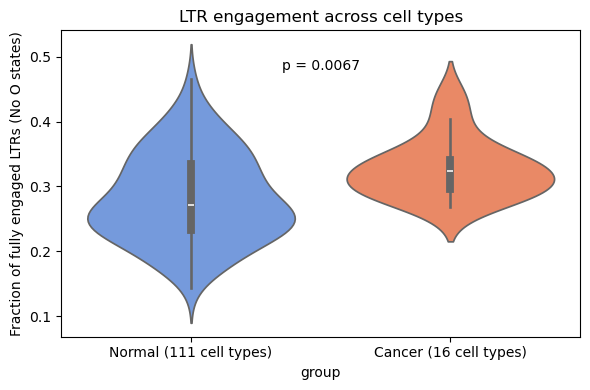

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt


palette = {
    "Normal": "cornflowerblue",
    "Cancer": "coral"
}

plt.figure(figsize=(6,4))

sns.violinplot(
    data=summary_per_cell,
    x="group",
    y="frac_engaged",  # O ratio is zero for fully engaged, so we can directly use it
    inner="box",
    palette=palette
)

plt.ylabel("Fraction of fully engaged LTRs (No O states)")
plt.title("LTR engagement across cell types")
plt.text(0.5, 0.48, "p = 0.0067", ha='center')
plt.xticks([0, 1], ["Normal (111 cell types)", "Cancer (16 cell types)"])
plt.tight_layout()
plt.show()

In [62]:
df_normal = df_all[~df_all["is_cancer"]].copy()
df_cancer = df_all[df_all["is_cancer"]].copy()

In [63]:
print(df_normal.shape)
print(df_cancer.shape)

(74650203, 14)
(10713224, 14)


<Axes: >

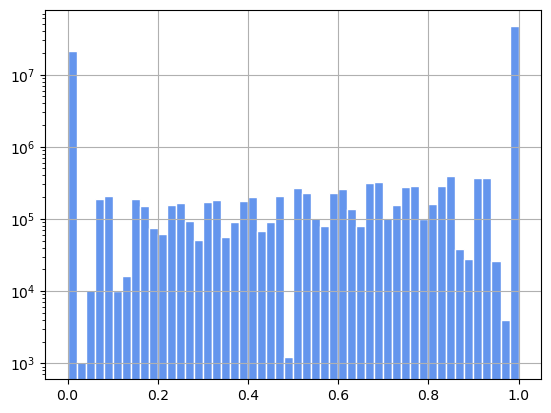

In [ ]:
df_normal["O_ratio"].hist(bins=50, log=True, color="cornflowerblue", edgecolor="white")

<Axes: >

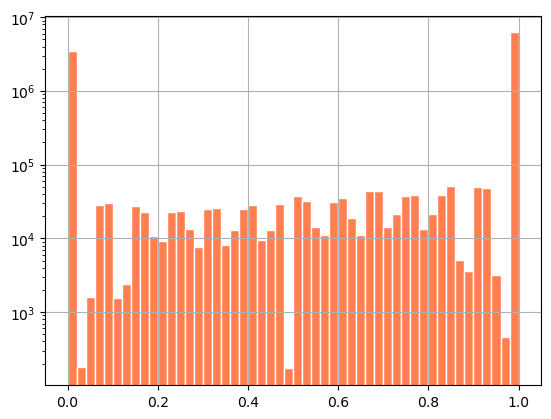

In [ ]:
df_cancer["O_ratio"].hist(bins=50, log=True, color="coral", edgecolor="white")

In [66]:
print((df_normal["O_ratio"] == 1).mean())
print((df_normal["O_ratio"] == 0).mean())

0.6202536247624135
0.28275435500155305


In [67]:
print((df_cancer["O_ratio"] == 1).mean())
print((df_cancer["O_ratio"] == 0).mean())

0.578746883291155
0.3275929822805908


### Fully engaged case (No O state)

In [68]:
from collections import Counter

def state_counts(seq):
    return Counter(seq)

df_normal_engaged = df_normal[df_normal["O_ratio"] == 0]
df_cancer_engaged = df_cancer[df_cancer["O_ratio"] == 0]

In [69]:
df_normal_engaged

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer,O_ratio
174,chr1,634542,636856,LTR39,3635.0,-,2314,NNNNNNNNNMMMM,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
175,chr1,635155,637458,LTR39,3635.0,-,2303,NNNNNNMMMMMMM,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
176,chr1,635578,637722,LTR39,3635.0,-,2144,NNNNMMMMMMMM,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
177,chr1,637233,639361,LTR33,473.0,+,2128,MMMNNNNNMMM,11,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
178,chr1,639608,641898,MLT1H,586.0,-,2290,MMMMMMMMMMMM,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74650198,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0
74650199,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0
74650200,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0
74650201,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0


In [70]:
df_cancer_engaged

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer,O_ratio
74650377,chr1,634542,636856,LTR39,3635.0,-,2314,NNNNNNNNNNNNN,13,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650378,chr1,635155,637458,LTR39,3635.0,-,2303,NNNNNNNNNNNNN,13,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650379,chr1,635578,637722,LTR39,3635.0,-,2144,NNNNNNNNNNNN,12,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650380,chr1,637233,639361,LTR33,473.0,+,2128,NNNNNNNNNNN,11,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650381,chr1,639608,641898,MLT1H,586.0,-,2290,NNNNNNNNNNNN,12,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85363422,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363423,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363424,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363425,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0


In [41]:
from collections import Counter

all_seq_normal_engaged = "".join(df_normal_engaged["state_seq_full_slice"].dropna())
all_seq_cancer_engaged = "".join(df_cancer_engaged["state_seq_full_slice"].dropna())

state_counts_normal_engaged = Counter(all_seq_normal_engaged)
state_counts_cancer_engaged = Counter(all_seq_cancer_engaged)

In [71]:
total_normal_engaged = sum(state_counts_normal_engaged.values())
total_cancer_engaged = sum(state_counts_cancer_engaged.values())

state_freq_normal_engaged = {k: v / total_normal_engaged for k, v in state_counts_normal_engaged.items()}
state_freq_cancer_engaged = {k: v / total_cancer_engaged for k, v in state_counts_cancer_engaged.items()}

In [72]:
import matplotlib.pyplot as plt

# A~O order
state_order = list("ABCDEFGHIJKLMNO")

# fill 0 for missing states
state_freq_ordered_normal_engaged = {k: state_freq_normal_engaged.get(k, 0) for k in state_order}
state_freq_ordered_cancer_engaged = {k: state_freq_cancer_engaged.get(k, 0) for k in state_order}

# color mapping based on ChromBERT's state_col_dict_num
colors = [crb.state_col_dict_num[k] for k in state_order]

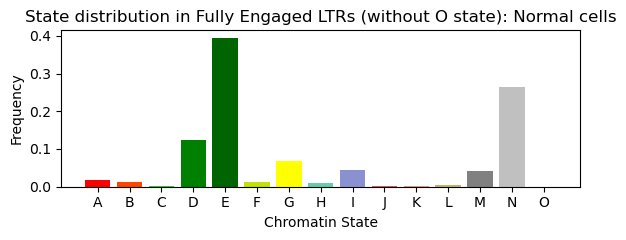

In [83]:
# plot normal
plt.figure(figsize=(6,2.5))
plt.bar(state_order, state_freq_ordered_normal_engaged.values(), color=colors)

plt.xlabel("Chromatin State")
plt.ylabel("Frequency")
plt.title("State distribution in Fully Engaged LTRs (without O state): Normal cells")

plt.tight_layout()
plt.show()

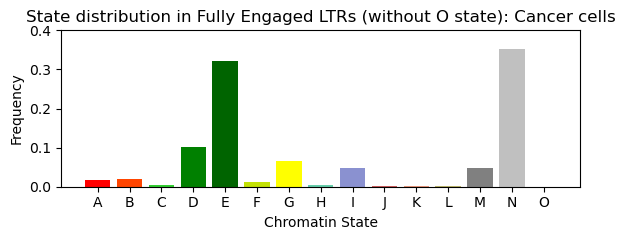

In [84]:
# plot cancer
plt.figure(figsize=(6,2.5))
plt.bar(state_order, state_freq_ordered_cancer_engaged.values(), color=colors)

plt.xlabel("Chromatin State")
plt.ylabel("Frequency")
plt.title("State distribution in Fully Engaged LTRs (without O state): Cancer cells")
plt.ylim(0,0.4)
plt.tight_layout()
plt.show()

In [86]:
from collections import Counter

def get_state_freq(df):
    all_seq = "".join(df["state_seq_full_slice"].dropna())
    counts = Counter(all_seq)
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

normal_freq = get_state_freq(df_normal_engaged)
cancer_freq = get_state_freq(df_cancer_engaged)

diff = {
    k: cancer_freq.get(k, 0) - normal_freq.get(k, 0)
    for k in state_order
}

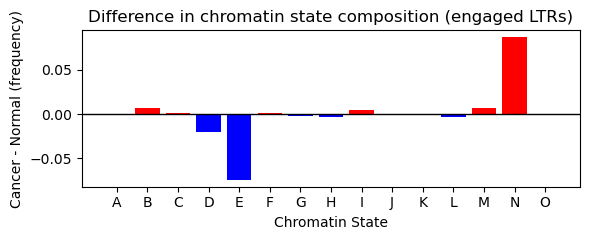

In [100]:
plt.figure(figsize=(6,2.5))

colors = ["red" if v > 0 else "blue" for v in diff.values()]

plt.bar(state_order, diff.values(), color=colors)
# plt.bar(state_order, diff.values(), color="silver")
plt.axhline(0, color='black', linewidth=1)

plt.xlabel("Chromatin State")
plt.ylabel("Cancer - Normal (frequency)")
plt.title("Difference in chromatin state composition (engaged LTRs)")

plt.tight_layout()
plt.show()

**Fully engaged LTRs exhibit similar chromatin state compositions between normal and cancer cells.**

In [102]:
def state_fraction_per_cell(df, state):
    return (
        df.groupby("cell_id")["state_seq_full_slice"]
        .apply(lambda x: sum(s.count(state) for s in x) / sum(len(s) for s in x))
    )

In [103]:
state = "E"

frac_per_cell = state_fraction_per_cell(df_all[df_all["O_ratio"] == 0], state)

summary = frac_per_cell.reset_index(name="frac")
summary["is_cancer"] = summary["cell_id"].map(
    df_all.groupby("cell_id")["is_cancer"].first()
)

from scipy.stats import mannwhitneyu

normal = summary[summary["is_cancer"] == False]["frac"]
cancer = summary[summary["is_cancer"] == True]["frac"]

stat, p = mannwhitneyu(normal, cancer)
print(p)

0.005451895280150077


In [104]:
state = "N"

frac_per_cell = state_fraction_per_cell(df_all[df_all["O_ratio"] == 0], state)

summary = frac_per_cell.reset_index(name="frac")
summary["is_cancer"] = summary["cell_id"].map(
    df_all.groupby("cell_id")["is_cancer"].first()
)

from scipy.stats import mannwhitneyu

normal = summary[summary["is_cancer"] == False]["frac"]
cancer = summary[summary["is_cancer"] == True]["frac"]

stat, p = mannwhitneyu(normal, cancer)
print(p)

7.619843621221474e-05


# Predict normal vs cancer from LTR chromatin-state features

## 1. Add the first baseline features

In [ ]:
# Step A: Add transition count

def count_transitions(seq):
    return sum(1 for i in range(len(seq) - 1) if seq[i] != seq[i + 1])

In [107]:
df_all["n_transitions"] = df_all["state_seq_full_slice"].apply(count_transitions)
df_all["transition_density"] = df_all["n_transitions"] / df_all["n_bins"]

In [108]:
# Step B: Add number of unique states
df_all["n_unique_states"] = df_all["state_seq_full_slice"].apply(lambda s: len(set(s)))

In [109]:
# Step C: Add entorpy
import math
from collections import Counter

def seq_entropy(seq):
    counts = Counter(seq)
    total = len(seq)
    probs = [c / total for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)

df_all["entropy"] = df_all["state_seq_full_slice"].apply(seq_entropy)

In [110]:
# Step D: Add per-state fractions
state_order = list("ABCDEFGHIJKLMNO")

for state in state_order:
    df_all[f"frac_{state}"] = df_all["state_seq_full_slice"].apply(lambda s: s.count(state) / len(s))

In [112]:
df_all.head()

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,...,frac_F,frac_G,frac_H,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O
0,chr1,20948,23075,MLT1K,254.0,+,2127,OOOOOOOOOOOO,12,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,chr1,29693,31848,MLT1A,741.0,+,2155,OOOOOOOOOOOO,12,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,chr1,29952,32131,MLT1A,741.0,+,2179,OOOOOOOOOOOO,12,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,chr1,33564,35921,MLT1J2,850.0,-,2357,OOOOOOOOOOOOO,13,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,chr1,37255,40464,MLT1E1A-int,3877.0,+,3209,OOOOOOOOOOOOOOOOO,17,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [113]:
# Save a feature table with all the calculated features for downstream analysis

feature_cols = [
    "cell_id", "is_cancer", "chrom", "start", "end", "name",
    "length", "n_bins", "O_ratio",
    "n_transitions", "transition_density", "n_unique_states", "entropy"
] + [f"frac_{s}" for s in state_order]

df_features = df_all[feature_cols].copy()
df_features.to_csv("../processed/ltr_feature_table.csv", index=False)